<a href="https://colab.research.google.com/github/RiyaH2020/Applied-Machine-Learning/blob/main/Assignment_5/Task_2_Sentiment_Analysis/MDS202431_AML_Assignment_5_Task_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Name: Riya Shyam Huddar
### Roll No.: MDS202431
### AML Assignment 5 Task 2 : Transfer Learning for text data using Transformer


In [ ]:
# Imports
import shutil
import os
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch

### Task: Sentiment Analysis using Transfer Learning

The objective of this assignment is to build a sentiment analysis classifier using a pre-trained Transformer model.

We use a dataset containing text data labeled with three sentiment classes:
- Negative  
- Neutral  
- Positive  

A pre-trained Transformer model (BERT) is fine-tuned on this dataset to perform multi-class classification.

The final model is evaluated using standard metrics such as accuracy, precision, recall, F1-score, and ROC-AUC.

In [ ]:
!pip install transformers==4.46.1 accelerate==0.34.2 datasets==2.21.0

### Data Acquisition and Setup

The sentiment analysis dataset was downloaded from Kaggle using the Kaggle API.  
The dataset was provided as a compressed (.zip) file and extracted within the working environment.

To ensure persistence across sessions, the extracted dataset was copied to Google Drive.  
This allows easy access to the data without needing to download it again in future runs.

The dataset consists of training and test CSV files containing text data along with corresponding sentiment labels.

In [ ]:
!kaggle datasets download -d abhi8923shriv/sentiment-analysis-dataset

Dataset URL: https://www.kaggle.com/datasets/abhi8923shriv/sentiment-analysis-dataset
License(s): CC0-1.0
100% 54.4M/54.4M [00:04<00:00, 12.0MB/s]



In [ ]:
from google.colab import drive
# Mount drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import drive

# Create a folder in Drive
drive_path = '/content/drive/MyDrive/sentiment_dataset'
os.makedirs(drive_path, exist_ok=True)

# Copy all current files (from Colab working directory) to Drive
for file in os.listdir():
    if file.endswith('.csv') or file.endswith('.txt'):
        shutil.copy(file, drive_path)

print("Files copied to:", drive_path)

Files copied to: /content/drive/MyDrive/sentiment_dataset


In [ ]:
from google.colab import drive

# Find the zip file
zip_files = [f for f in os.listdir() if f.endswith('.zip')]
print("Zip files:", zip_files)

# Extract
zip_path = zip_files[0]

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('dataset')

print("Extracted files:", os.listdir('dataset'))

# Copy extracted folder to Drive
destination = '/content/drive/MyDrive/sentiment_dataset'
shutil.copytree('dataset', destination, dirs_exist_ok=True)

print("Files in Drive:", os.listdir(destination))

Zip files: ['sentiment-analysis-dataset.zip']
Extracted files: ['test.csv', 'train.csv', 'testdata.manual.2009.06.14.csv', 'training.1600000.processed.noemoticon.csv']
Files in Drive: ['test.csv', 'train.csv', 'testdata.manual.2009.06.14.csv', 'training.1600000.processed.noemoticon.csv']


### 1. Dataset Overview

The dataset was loaded into training and test sets, containing text data and sentiment labels (negative, neutral, positive).

- Training set: ~27k samples  
- Test set: ~4.8k samples  

Missing text and sentiment values were removed.

The dataset shows a slight class imbalance, with neutral being the most common class.

Text lengths vary, but are generally short, making the dataset suitable for transformer-based models.

In [ ]:
drive_path = '/content/drive/MyDrive/sentiment_dataset'

train_path = os.path.join(drive_path, 'train.csv')
test_path = os.path.join(drive_path, 'test.csv')

train_df = pd.read_csv(train_path, encoding='latin-1')
test_df = pd.read_csv(test_path, encoding='latin-1')

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("\nColumns:", train_df.columns)

train_df.head()

Train shape: (27481, 10)
Test shape: (4815, 9)

Columns: Index(['textID', 'text', 'selected_text', 'sentiment', 'Time of Tweet',
       'Age of User', 'Country', 'Population -2020', 'Land Area (Km²)',
       'Density (P/Km²)'],
      dtype='object')


,textID,text,selected_text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral,morning,0-20,Afghanistan,38928346,652860.0,60
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative,noon,21-30,Albania,2877797,27400.0,105
2,088c60f138,my boss is bullying me...,bullying me,negative,night,31-45,Algeria,43851044,2381740.0,18
3,9642c003ef,what interview! leave me alone,leave me alone,negative,morning,46-60,Andorra,77265,470.0,164
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative,noon,60-70,Angola,32866272,1246700.0,26


In [ ]:
# 1. Missing values (train)
print("Missing values (train):\n", train_df.isnull().sum())

# Drop rows where text is missing
train_df = train_df.dropna(subset=['text'])

print("\nAfter dropping missing text:")
print(train_df.isnull().sum())

# 2. Handle missing sentiment in test set
nan_count = test_df['sentiment'].isnull().sum()
print("\nMissing sentiment in test set:", nan_count)

# Drop missing sentiment rows
test_df = test_df.dropna(subset=['sentiment'])

print("After dropping missing sentiment (test):", test_df['sentiment'].isnull().sum())

# 3. Label distribution
print("\nLabel distribution:\n", train_df['sentiment'].value_counts())

# 4. Sample texts
print("\nSample texts:")
for i in range(3):
    print(f"\nExample {i+1}:")
    print(train_df['text'].iloc[i])

# 5. Text length distribution
train_df['text_length'] = train_df['text'].apply(len)

print("\nText length stats:")
print(train_df['text_length'].describe())

Missing values (train):
 textID              0
text                1
selected_text       1
sentiment           0
Time of Tweet       0
Age of User         0
Country             0
Population -2020    0
Land Area (Km²)     0
Density (P/Km²)     0
dtype: int64

After dropping missing text:
textID              0
text                0
selected_text       0
sentiment           0
Time of Tweet       0
Age of User         0
Country             0
Population -2020    0
Land Area (Km²)     0
Density (P/Km²)     0
dtype: int64

Missing sentiment in test set: 1281
After dropping missing sentiment (test): 0

Label distribution:
 sentiment
neutral     11117
positive     8582
negative     7781
Name: count, dtype: int64

Sample texts:

Example 1:
 I`d have responded, if I were going

Example 2:
 Sooo SAD I will miss you here in San Diego!!!

Example 3:
my boss is bullying me...

Text length stats:
count    27480.000000
mean        68.354949
std         35.624417
min          3.000000
25%         39.000

# Exploratory Data Analysis (EDA)

Basic analysis was performed to understand the dataset.

- No missing values are present after preprocessing.  
- The dataset shows a slight class imbalance, with neutral being the most frequent sentiment.  
- Sample texts indicate informal and short tweet-like data.  
- Text length varies, with an average of around 68 characters.  

Visualizations show:
- Distribution of sentiment classes  
- Distribution of text lengths  
- Average text length across different sentiments  

In [ ]:
# 1. Missing values
print("Missing values (train):\n", train_df.isnull().sum())

# 2. Label distribution
print("\nLabel distribution:\n", train_df['sentiment'].value_counts())

# 3. Basic text inspection
print("\nSample texts:")
for i in range(3):
    print(f"\nExample {i+1}:")
    print(train_df['text'].iloc[i])

# 4. Text length distribution
train_df['text_length'] = train_df['text'].apply(len)

print("\nText length stats:")
print(train_df['text_length'].describe())

Missing values (train):
 textID              0
text                0
selected_text       0
sentiment           0
Time of Tweet       0
Age of User         0
Country             0
Population -2020    0
Land Area (Km²)     0
Density (P/Km²)     0
text_length         0
dtype: int64

Label distribution:
 sentiment
neutral     11117
positive     8582
negative     7781
Name: count, dtype: int64

Sample texts:

Example 1:
 I`d have responded, if I were going

Example 2:
 Sooo SAD I will miss you here in San Diego!!!

Example 3:
my boss is bullying me...

Text length stats:
count    27480.000000
mean        68.354949
std         35.624417
min          3.000000
25%         39.000000
50%         64.000000
75%         97.000000
max        159.000000
Name: text_length, dtype: float64


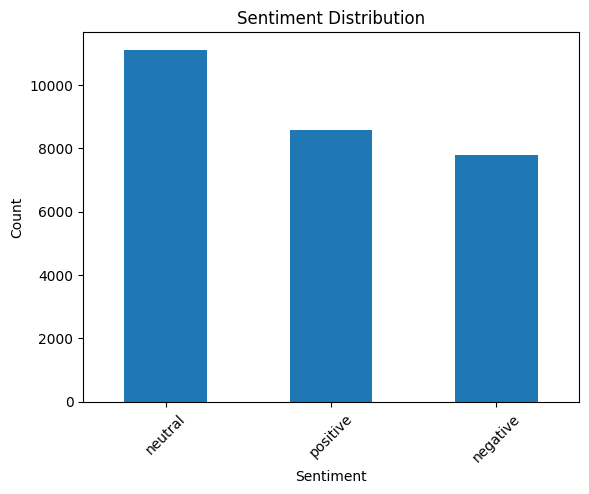

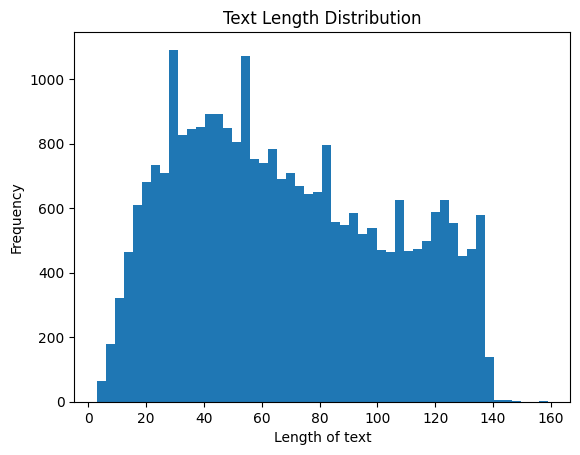

In [ ]:
# 1. Class distribution
train_df['sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.show()

# 2. Text length distribution
train_df['text_length'] = train_df['text'].apply(len)

plt.hist(train_df['text_length'], bins=50)
plt.title("Text Length Distribution")
plt.xlabel("Length of text")
plt.ylabel("Frequency")
plt.show()

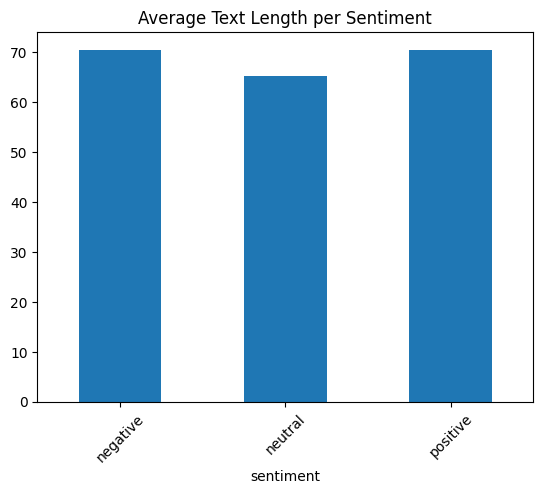

In [ ]:
# Average length per sentiment
train_df.groupby('sentiment')['text_length'].mean().plot(kind='bar')
plt.title("Average Text Length per Sentiment")
plt.xticks(rotation=45)
plt.show()

# Sentiment vs Other Features

The relationship between sentiment and additional features was analyzed.

- Sentiment distribution varies slightly across different times of the day.
- Across age groups, sentiment patterns remain relatively similar with no strong variation.

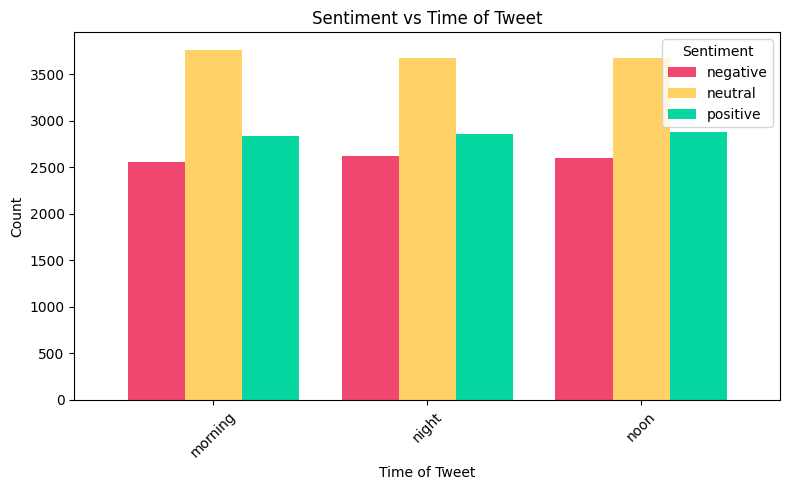

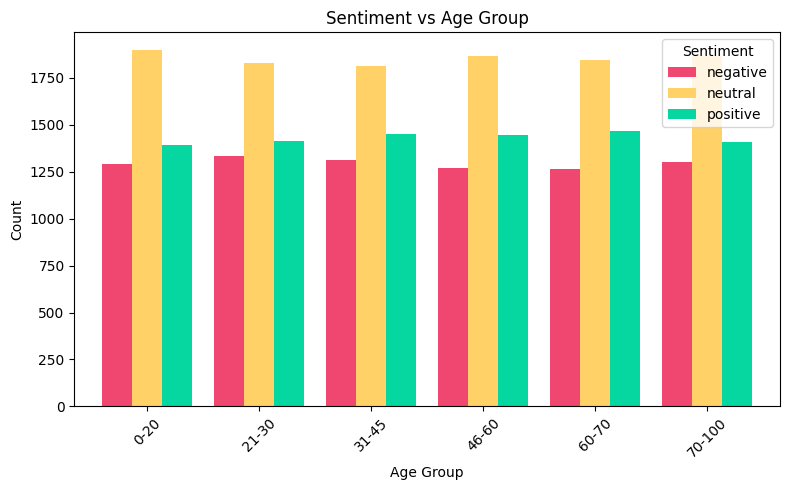

In [ ]:
import matplotlib.pyplot as plt

colors = ['#ef476f', '#ffd166', '#06d6a0']

# Helper function
def plot_grouped_bar(index_col, title, xlabel):
    ct = pd.crosstab(train_df[index_col], train_df['sentiment'])

    ax = ct.plot(
        kind='bar',
        figsize=(8,5),
        color=colors,
        width=0.8
    )

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.legend(title="Sentiment")
    plt.tight_layout()
    plt.show()

# 1. Sentiment vs Time of Tweet
plot_grouped_bar('Time of Tweet', "Sentiment vs Time of Tweet", "Time of Tweet")

# 2. Sentiment vs Age Group
plot_grouped_bar('Age of User', "Sentiment vs Age Group", "Age Group")


### 2. Text Cleaning

Basic preprocessing was applied to prepare the text for the transformer model.

- URLs were removed  
- HTML entities were cleaned  
- Extra whitespace was normalized  

Minimal cleaning was performed since BERT tokenization can handle casing and punctuation effectively.

In [ ]:
import re

def clean_text(text):
    text = str(text)

    text = re.sub(r'http\S+|www\.\S+', '', text)  # remove URLs
    text = re.sub(r'&amp;', '&', text)            # fix HTML entity
    text = re.sub(r'\s+', ' ', text).strip()      # normalize whitespace

    return text

train_df['text'] = train_df['text'].apply(clean_text)
test_df['text'] = test_df['text'].apply(clean_text)

# Show a few cleaned examples
print(train_df[['text', 'sentiment']].head(5))

print("\n--- More samples ---\n")
for i in range(3):
    print(f"Example {i+1}:")
    print(train_df['text'].iloc[i])
    print()

                                                text sentiment
0                I`d have responded, if I were going   neutral
1      Sooo SAD I will miss you here in San Diego!!!  negative
2                          my boss is bullying me...  negative
3                     what interview! leave me alone  negative
4  Sons of ****, why couldn`t they put them on th...  negative

--- More samples ---

Example 1:
I`d have responded, if I were going

Example 2:
Sooo SAD I will miss you here in San Diego!!!

Example 3:
my boss is bullying me...



### Label Encoding

Sentiment labels were converted from text to numeric format for model training.

- Negative -> 0  
- Neutral -> 1  
- Positive -> 2  

Labels were standardized (lowercased and stripped) before mapping.  
All missing values were removed to ensure consistency.

In [ ]:
# Drop rows with missing sentiment BEFORE mapping
test_df = test_df.dropna(subset=['sentiment'])
train_df = train_df.dropna(subset=['sentiment'])

# Standardize labels
train_df['sentiment'] = train_df['sentiment'].str.strip().str.lower()
test_df['sentiment'] = test_df['sentiment'].str.strip().str.lower()

# Mapping
label_map = {'negative': 0, 'neutral': 1, 'positive': 2}

train_df['label'] = train_df['sentiment'].map(label_map)
test_df['label'] = test_df['sentiment'].map(label_map)

# Convert to int
train_df['label'] = train_df['label'].astype(int)
test_df['label'] = test_df['label'].astype(int)

# Final check
print("Train missing labels:", train_df['label'].isnull().sum())
print("Test missing labels:", test_df['label'].isnull().sum())

print("\nSample:")
print(train_df[['text', 'sentiment', 'label']].head())

Train missing labels: 0
Test missing labels: 0

Sample:
                                                text sentiment  label
0                I`d have responded, if I were going   neutral      1
1      Sooo SAD I will miss you here in San Diego!!!  negative      0
2                          my boss is bullying me...  negative      0
3                     what interview! leave me alone  negative      0
4  Sons of ****, why couldn`t they put them on th...  negative      0


### Train-Validation Split

The dataset was split into training and validation sets using stratified sampling.

- Training set: 90%  
- Validation set: 10%  

Stratification ensures that the distribution of sentiment classes remains consistent across both sets.

After preprocessing (removal of missing sentiment labels), the test set contains **3534 samples** and is used only for final evaluation.

In [ ]:
from sklearn.model_selection import train_test_split

# Split (90% train, 10% validation)
train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_df['text'],
    train_df['label'],
    test_size=0.1,
    stratify=train_df['label'],
    random_state=42
)

# Print sizes
print("Train size:", len(train_texts))
print("Validation size:", len(val_texts))
print("Test size:", len(test_df))

Train size: 24732
Validation size: 2748
Test size: 3534


In [ ]:
print("Train distribution:\n", pd.Series(train_labels).value_counts(normalize=True))
print("\nValidation distribution:\n", pd.Series(val_labels).value_counts(normalize=True))

Train distribution:
 label
1    0.404537
2    0.312308
0    0.283155
Name: proportion, dtype: float64

Validation distribution:
 label
1    0.404658
2    0.312227
0    0.283115
Name: proportion, dtype: float64


### Tokenization

Text data was converted into numerical format using the BERT tokenizer.

- Each sentence is split into tokens and mapped to token IDs  
- Padding and truncation were applied to ensure uniform sequence length  
- Maximum sequence length was set to 128  

The tokenizer also generates attention masks to indicate valid tokens.

In [ ]:
from transformers import AutoTokenizer

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

print("Tokenizer loaded successfully")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded successfully


In [ ]:
# Tokenize datasets

train_encodings = tokenizer(
    list(train_texts),
    padding=True,
    truncation=True,
    max_length=128
)

val_encodings = tokenizer(
    list(val_texts),
    padding=True,
    truncation=True,
    max_length=128
)

test_encodings = tokenizer(
    list(test_df['text']),
    padding=True,
    truncation=True,
    max_length=128
)

print("Tokenization complete")

Tokenization complete


In [ ]:
# Inspect one example
print("Input IDs:", train_encodings['input_ids'][0][:20])
print("Attention Mask:", train_encodings['attention_mask'][0][:20])

Input IDs: [101, 1035, 1018, 2851, 1010, 2074, 9361, 2017, 2064, 2145, 2424, 2115, 1056, 2860, 11961, 2140, 102, 0, 0, 0]
Attention Mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0]


### Dataset Preparation

A custom PyTorch Dataset class was created to prepare the data for model training.

- Tokenized inputs (input IDs and attention masks) are converted into tensors  
- Corresponding sentiment labels are attached to each sample  
- Separate datasets were created for training, validation, and testing

In [ ]:
class SentimentDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = list(labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

In [ ]:
train_dataset = SentimentDataset(train_encodings, train_labels)
val_dataset = SentimentDataset(val_encodings, val_labels)
test_dataset = SentimentDataset(test_encodings, test_df['label'])

print("Datasets created successfully")

Datasets created successfully


In [ ]:
sample = train_dataset[0]
print(sample.keys())
print(sample['input_ids'][:10])
print(sample['labels'])

dict_keys(['input_ids', 'token_type_ids', 'attention_mask', 'labels'])
tensor([ 101, 1035, 1018, 2851, 1010, 2074, 9361, 2017, 2064, 2145])
tensor(1)


### 3. Model Initialization

A pre-trained BERT model was loaded for sequence classification.

- Model: bert-base-uncased  
- The classification head was modified to output 3 labels (negative, neutral, positive).

In [ ]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=3
)

print("Model loaded successfully")

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded successfully


### Training Configuration

Training parameters were defined to control the fine-tuning process.

- Number of epochs: 3  
- Batch size: 16  
- Learning rate: 2e-5 with cosine scheduler  
- Warmup and weight decay applied for stable training  

Evaluation and logging were performed at regular step intervals to monitor performance.

The best model was automatically selected based on F1-score on the validation set.

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir='./results',

    # Training control
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    learning_rate=2e-5,
    lr_scheduler_type="cosine",
    warmup_ratio=0.1,
    weight_decay=0.01,

    eval_strategy="steps",
    eval_steps=500,

    # Logging
    logging_dir='./logs',
    logging_strategy="steps",
    logging_steps=100,

    # Performance
    load_best_model_at_end=True,
    metric_for_best_model="f1",

    # Disable unnecessary warnings
    report_to="none"
)

### Evaluation Metrics

Custom evaluation metrics were defined to assess model performance.

- Accuracy: overall correctness of predictions  
- Precision: correctness of positive predictions  
- Recall: ability to capture all relevant instances  
- F1-score: harmonic mean of precision and recall  

Weighted averaging was used to account for class imbalance.

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(pred):
    logits, labels = pred
    preds = logits.argmax(axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average='weighted'
    )
    acc = accuracy_score(labels, preds)

    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

### Trainer Setup

The Hugging Face Trainer API was used to manage the training and evaluation process.

- Handles training loop, evaluation, and logging  
- Uses the defined model, datasets, tokenizer, and metrics  
- Simplifies fine-tuning of the transformer model  

The trainer is now ready to begin model training.

In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,  # updated
    compute_metrics=compute_metrics
)

print("Trainer ready")

Trainer ready


### Model Training and Validation

The model was fine-tuned on the training data and evaluated on the validation set.

### Results:
- Accuracy: ~0.80  
- F1-score: ~0.80  
- Precision: ~0.80  
- Recall: ~0.80  

### Observation:
The model shows strong and consistent performance across all metrics, indicating effective learning and good generalization on unseen data.

In [ ]:
# 1. Start the actual fine-tuning process
print("Starting training...")
trainer.train()

# 2. Evaluate on the validation set to see the improvement
print("\n--- Validation Results ---")
eval_results = trainer.evaluate()
print(eval_results)

# 3. Final check: Predict on the test set
predictions = trainer.predict(test_dataset)

Starting training...


Step,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
500,0.664700,0.592027,0.755822,0.755378,0.756796,0.755822
1000,0.591400,0.548062,0.779840,0.779615,0.779857,0.779840
1500,0.538900,0.571412,0.789665,0.790435,0.797455,0.789665
2000,0.445200,0.551424,0.789301,0.789574,0.793943,0.789301
2500,0.390600,0.562777,0.792940,0.792843,0.793992,0.792940
3000,0.404700,0.539117,0.799127,0.798821,0.798892,0.799127
3500,0.292600,0.611851,0.799491,0.799586,0.800275,0.799491
4000,0.304300,0.614783,0.797307,0.797640,0.798711,0.797307
4500,0.292300,0.618047,0.800218,0.800401,0.801115,0.800218



--- Validation Results ---


{'eval_loss': 0.6180466413497925, 'eval_accuracy': 0.8002183406113537, 'eval_f1': 0.8004007960999688, 'eval_precision': 0.8011152261066945, 'eval_recall': 0.8002183406113537, 'eval_runtime': 12.5382, 'eval_samples_per_second': 219.171, 'eval_steps_per_second': 13.718, 'epoch': 3.0}


In [ ]:
df_logs = pd.DataFrame(trainer.state.log_history)

### Training Loss Curve

The training loss was plotted over steps to monitor the learning process.

- The loss decreases steadily, indicating effective learning  
- Rapid decline in early steps shows quick pattern capture  
- Gradual decrease later suggests convergence  

Overall, the model training is stable and shows no signs of divergence.

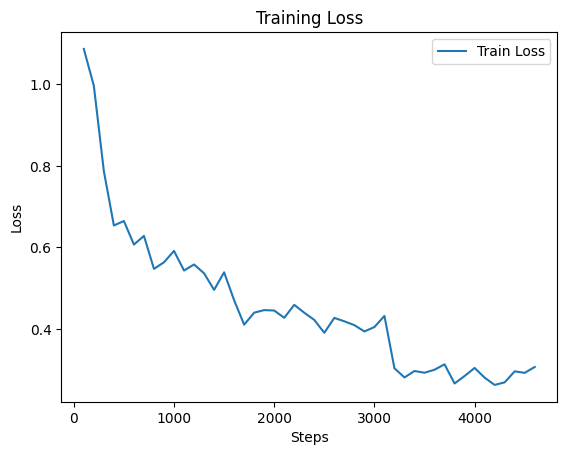

In [ ]:
# Training loss
train_loss = df_logs[df_logs['loss'].notnull()]

plt.figure()

# Plot training loss
plt.plot(train_loss['step'], train_loss['loss'], label='Train Loss')


plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.legend()

plt.show()

### Test Set Evaluation

The model was evaluated on the held-out test set using a classification report.

### Results:
- Accuracy: ~0.79  
- F1-score: ~0.79  

### Class-wise Performance:
- Negative: F1 ≈ 0.79  
- Neutral: F1 ≈ 0.76  
- Positive: F1 ≈ 0.84  

### Observation:
The model performs well across all classes, with slightly better performance on positive sentiment and comparatively lower performance on neutral sentiment.

Overall, the model generalizes well to unseen data.

In [ ]:
from sklearn.metrics import classification_report

# Predictions
y_pred = predictions.predictions.argmax(axis=1)
y_true = predictions.label_ids

print(classification_report(
    y_true,
    y_pred,
    target_names=['negative', 'neutral', 'positive']
))

              precision    recall  f1-score   support

    negative       0.77      0.81      0.79      1001
     neutral       0.76      0.75      0.76      1430
    positive       0.85      0.83      0.84      1103

    accuracy                           0.79      3534
   macro avg       0.80      0.80      0.80      3534
weighted avg       0.79      0.79      0.79      3534



### Confusion Matrix Analysis

The confusion matrix provides a detailed view of model predictions across classes.

### Observations:
- Most predictions lie along the diagonal, indicating correct classifications.  
- Negative and positive sentiments are classified with good accuracy.  
- The model shows some confusion between:
  - Neutral and negative  
  - Neutral and positive  

### Interpretation:
- Neutral sentiment is harder to distinguish due to its ambiguous nature.  
- The model performs best on clearly polarized sentiments (positive and negative).  

Overall, the confusion matrix confirms strong performance with minor misclassifications in borderline cases.

<Figure size 640x480 with 0 Axes>

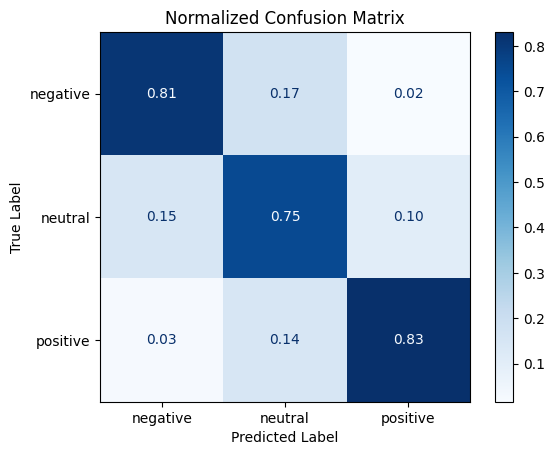

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


# Compute normalized confusion matrix (row-wise)
cm = confusion_matrix(y_true, y_pred, normalize='true')

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['negative', 'neutral', 'positive']
)

plt.figure()
disp.plot(cmap='Blues', values_format='.2f')  # show percentages

plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

### ROC Curve Analysis

ROC curves were plotted using a one-vs-rest approach for the three sentiment classes.

### Results:
- Negative: AUC ≈ 0.94  
- Neutral: AUC ≈ 0.90  
- Positive: AUC ≈ 0.95  
- Overall ROC-AUC: ≈ 0.93  

### Observation:
- All classes show strong performance with curves close to the top-left corner.  
- The model performs best on positive and negative classes.  
- Neutral sentiment is slightly harder to distinguish.

The high ROC-AUC compared to accuracy indicates that the model effectively ranks class probabilities, with most errors occurring in borderline cases rather than completely incorrect predictions.

In [ ]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

# Probabilities
y_prob = predictions.predictions

# One-hot encode true labels
y_true_bin = label_binarize(y_true, classes=[0, 1, 2])

roc_auc = roc_auc_score(y_true_bin, y_prob, multi_class='ovr')

print("ROC-AUC (OvR):", roc_auc)

ROC-AUC (OvR): 0.9271325707217857


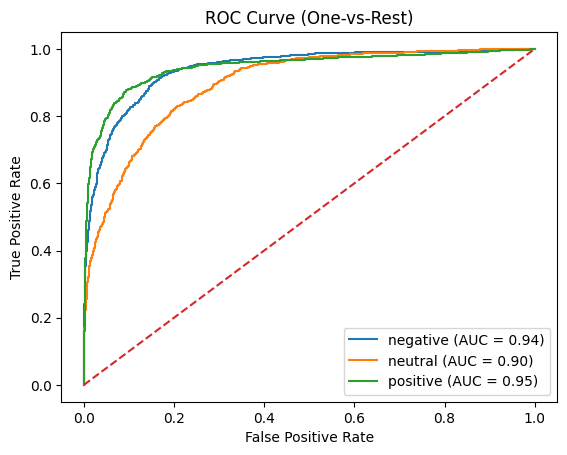

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize labels
y_true_bin = label_binarize(y_true, classes=[0, 1, 2])

# Predicted probabilities
y_prob = predictions.predictions

# Class names
class_names = ['negative', 'neutral', 'positive']

plt.figure()

# Plot ROC for each class
for i in range(3):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC = {roc_auc:.2f})")

# Diagonal line (random classifier)
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (One-vs-Rest)")
plt.legend()

plt.show()

### Misclassification Analysis

Misclassified samples were analyzed to understand model limitations.

### Observations:
- Most errors occur between neutral and negative classes  
- Slightly negative tones are often classified as negative instead of neutral  
- Some positive samples without strong emotional cues are predicted as neutral  
- Informal, noisy, or non-standard text leads to incorrect predictions  
- Mixed or context-dependent sentences are harder to classify correctly  

### Conclusion:
The model performs well on clearly polarized sentiments but struggles with ambiguous and borderline cases, which is expected in natural language processing tasks.

In [ ]:
test_texts = test_df['text'].reset_index(drop=True)

results_df = pd.DataFrame({
    'text': test_texts,
    'true': y_true,
    'pred': y_pred
})

In [ ]:
misclassified = results_df[results_df['true'] != results_df['pred']]

print("Total misclassified:", len(misclassified))
misclassified.head(10)

Total misclassified: 733


,text,true,pred
19,"I`m going into a spiritual stagnentation, its ...",1,0
21,My dead grandpa pays more attention to me than...,0,1
26,"hey peoples, dont you just hate being grounded...",1,0
28,look who I found just for you --->,2,1
37,So I really need to put the laptop down & star...,1,0
40,4n? ma rog never heard of it esti beat acum? u...,0,1
41,I always forget SOMETHING when I travel. I am ...,1,0
50,Is watching acoustic performances! & In the mo...,1,0
57,almost got a kitty yesterday...but it didn`t w...,1,0
61,"_xo dang it, so its not certain ? ? ? are you ...",1,0


In [ ]:
label_map_reverse = {0: 'negative', 1: 'neutral', 2: 'positive'}

# copy
misclassified = misclassified.copy()

# Safe assignment
misclassified['true_label'] = misclassified['true'].map(label_map_reverse)
misclassified['pred_label'] = misclassified['pred'].map(label_map_reverse)

# Display
misclassified[['text', 'true_label', 'pred_label']].head(10)

,text,true_label,pred_label
19,"I`m going into a spiritual stagnentation, its ...",neutral,negative
21,My dead grandpa pays more attention to me than...,negative,neutral
26,"hey peoples, dont you just hate being grounded...",neutral,negative
28,look who I found just for you --->,positive,neutral
37,So I really need to put the laptop down & star...,neutral,negative
40,4n? ma rog never heard of it esti beat acum? u...,negative,neutral
41,I always forget SOMETHING when I travel. I am ...,neutral,negative
50,Is watching acoustic performances! & In the mo...,neutral,negative
57,almost got a kitty yesterday...but it didn`t w...,neutral,negative
61,"_xo dang it, so its not certain ? ? ? are you ...",neutral,negative


### Conclusion

In this assignment, the pre-trained **BERT (bert-base-uncased)** transformer model was used for sentiment classification.

BERT was chosen due to its strong contextual understanding of language and proven performance on text classification tasks. Its bidirectional architecture allows it to capture meaning more effectively compared to traditional models.

The model was fine-tuned on the dataset by:
- Adding a classification head for 3 sentiment classes  
- Training for 3 epochs on labeled data  
- Using a low learning rate with cosine scheduling and warmup  
- Evaluating periodically to select the best model based on F1-score  

### Results:
- Accuracy: ~0.79  
- F1-score: ~0.79  
- ROC-AUC: ~0.93  

### Final Observation:
The model performs well on clearly positive and negative sentiments, while neutral sentiment remains more challenging due to its ambiguous nature. Most errors occur in borderline or context-dependent cases.

Overall, the results demonstrate that fine-tuning a pre-trained transformer like BERT is highly effective for sentiment analysis tasks.